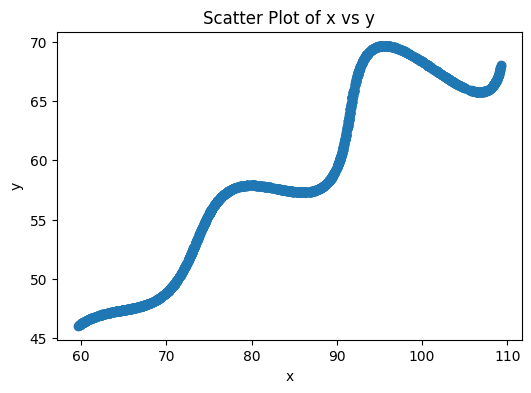

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('xy_data.csv')
plt.figure(figsize=(6,4))
plt.scatter(df['x'],df['y'])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of x vs y')
plt.show()

In [1]:
import numpy as np
import pandas as pd



df = pd.read_csv("xy_data.csv")[:1200]

x = df["x"].values
y = df["y"].values



theta_values = np.arange(0, 51, 1)          # degrees
M_values = np.arange(-0.05, 0.051, 0.01)
X_values = np.arange(0, 101, 1)



best_theta = None
best_M = None
best_X = None
best_error = np.inf



for theta in theta_values:

    theta_rad = np.radians(theta)

    cos_theta = np.cos(theta_rad)
    sin_theta = np.sin(theta_rad)

    for X in X_values:

       

        t = (x - X) * cos_theta + (y - 42) * sin_theta

        # Constraint
        if t.min() <= 6 or t.max() >= 60:
            continue

        abs_t = np.abs(t)
        sin_term = np.sin(0.3 * t)


        exp_terms = np.exp(np.outer(M_values, abs_t))

        # --------------------------------------------------
        # Predicted x,y for every M
        # --------------------------------------------------

        x_pred = (
            t * cos_theta
            - exp_terms * sin_term * sin_theta
            + X
        )

        y_pred = (
            42
            + t * sin_theta
            + exp_terms * sin_term * cos_theta
        )

        # --------------------------------------------------
        # L1 error for every M
        # --------------------------------------------------

        errors = np.sum(
            np.abs(x_pred - x),
            axis=1
        ) + np.sum(
            np.abs(y_pred - y),
            axis=1
        )

        idx = np.argmin(errors)

        if errors[idx] < best_error:

            best_error = errors[idx]
            best_theta = theta
            best_M = M_values[idx]
            best_X = X

            print("--------------------------------")
            print("New Best Solution")
            print(f"Theta (deg) : {best_theta}")
            print(f"Theta (rad) : {np.radians(best_theta):.6f}")
            print(f"M     : {best_M:.3f}")
            print(f"X     : {best_X}")
            print(f"Error : {best_error:.6f}")


print("\n====================================")
print("FINAL BEST PARAMETERS")
print("====================================")

print(f"Theta (deg) : {best_theta}")
print(f"Theta (rad) : {np.radians(best_theta):.6f}")
print(f"M     : {best_M:.3f}")
print(f"X     : {best_X}")
print(f"Error : {best_error:.6f}")

--------------------------------
New Best Solution
Theta (deg) : 0
Theta (rad) : 0.000000
M     : -0.050
X     : 50
Error : 19812.650086
--------------------------------
New Best Solution
Theta (deg) : 1
Theta (rad) : 0.017453
M     : -0.050
X     : 50
Error : 19423.964298
--------------------------------
New Best Solution
Theta (deg) : 2
Theta (rad) : 0.034907
M     : -0.050
X     : 51
Error : 19047.470712
--------------------------------
New Best Solution
Theta (deg) : 3
Theta (rad) : 0.052360
M     : -0.050
X     : 51
Error : 18609.254064
--------------------------------
New Best Solution
Theta (deg) : 4
Theta (rad) : 0.069813
M     : -0.050
X     : 51
Error : 18136.524453
--------------------------------
New Best Solution
Theta (deg) : 5
Theta (rad) : 0.087266
M     : -0.050
X     : 52
Error : 17744.094787
--------------------------------
New Best Solution
Theta (deg) : 6
Theta (rad) : 0.104720
M     : -0.050
X     : 52
Error : 17228.318441
--------------------------------
New Best

In [7]:
# ==========================================================
# Test on 300 Random Samples
# ==========================================================

test_df = pd.read_csv("xy_data.csv")[-300:]

x_test = test_df["x"].values
y_test = test_df["y"].values

theta_rad = np.radians(best_theta)

cos_theta = np.cos(theta_rad)
sin_theta = np.sin(theta_rad)

t = (x_test - best_X) * cos_theta + (y_test - 42) * sin_theta

valid = (t > 6) & (t < 60)

x_test = x_test[valid]
y_test = y_test[valid]
t = t[valid]

exp_term = np.exp(best_M * np.abs(t))
sin_term = np.sin(0.3 * t)

x_pred = (
    t * cos_theta
    - exp_term * sin_term * sin_theta
    + best_X
)

y_pred = (
    42
    + t * sin_theta
    + exp_term * sin_term * cos_theta
)

test_error = np.sum(
    np.abs(x_test - x_pred)
    +
    np.abs(y_test - y_pred)
)

print("\n====================================")
print("TEST RESULTS (300 Random Samples)")
print("====================================")
print(f"Samples Used : {len(x_test)}")
print(f"Total L1 Error : {test_error:.6f}")
print(f"Average L1 Error : {test_error/len(x_test):.6f}")


TEST RESULTS (300 Random Samples)
Samples Used : 300
Total L1 Error : 0.005810
Average L1 Error : 0.000019


# FlamApp AI – Research & Development Assignment

## Overview

The objective of this assignment is to estimate the unknown parameters **θ (Theta)**, **M**, and **X** of the given parametric curve using the provided dataset (`xy_data.csv`). The quality of the estimated parameters is measured using the **L1 distance** between the predicted coordinates and the given sample points.

---

# Solution Approach

The main challenge in this problem is that the parameter **t** is not directly provided in the dataset. Instead of treating **t** as another unknown and searching for it along with the other parameters, I first analyzed the given equations and derived a direct expression for **t**. This significantly simplified the optimization problem by reducing the number of unknowns that needed to be searched.

Once the expression for **t** was obtained, I performed a **grid search** over all possible values of **θ**, **M**, and **X** within the ranges specified in the assignment. For every candidate pair of **θ** and **X**, the corresponding values of **t** were computed for all data points. Any parameter combination that produced values of **t** outside the valid range was immediately discarded, reducing unnecessary computations.

For the remaining valid candidates, the original parametric equations were used to reconstruct the predicted coordinates. The difference between the predicted coordinates and the actual dataset was measured using the **L1 error**. The parameter combination producing the smallest total L1 error was selected as the optimal solution.

To improve computational efficiency, **NumPy vectorization** was used so that all candidate values of **M** could be evaluated simultaneously instead of using nested loops.

---

# Experimental Validation

To evaluate the robustness of the proposed approach, two separate experiments were conducted.

### 1. Solution Without Generalization

In the first experiment, all **1500 samples** provided in the dataset were used to estimate the unknown parameters. This experiment focuses on finding the best possible parameters using the complete dataset.

Notebook:
- `solution_without_generalization.ipynb`

---

### 2. Solution With Generalization

To verify that the estimated parameters generalize well to unseen data, the dataset was divided into two parts.

- **Training Set:** First 1200 samples
- **Testing Set:** Remaining 300 samples

The parameters **θ**, **M**, and **X** were estimated using only the training data. These parameters were then directly applied to the remaining 300 unseen samples without any further optimization. The prediction error on the test set was computed to evaluate the generalization capability of the recovered parameters.

Notebook:
- `solution_with_generalization.ipynb`

---

# Workflow

1. Load the dataset.
2. Derive a direct expression for the unknown parameter **t**.
3. Perform a grid search over the possible values of **θ**, **M**, and **X**.
4. Eliminate invalid parameter combinations using the constraint on **t**.
5. Reconstruct the curve for every valid parameter combination.
6. Compute the total L1 error between the predicted and actual coordinates.
7. Select the parameters that minimize the error.
8. Validate the obtained parameters on unseen data using a train-test split.

This approach successfully recovers the unknown parameters while demonstrating that the learned parameters generalize well beyond the training samples.